# Booking Intelligence Analysis

Enterprise booking behavior analysis for hotel demand, channels, lead time, and revenue performance.

In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
bookings = pd.read_csv(ROOT / 'data/processed/hotel_bookings_cleaned.csv', parse_dates=['arrival_date'])
monthly = pd.read_csv(ROOT / 'data/processed/monthly_demand.csv', parse_dates=['arrival_date'])
bookings.shape, monthly.shape

((119210, 64), (52, 24))

In [2]:
monthly.groupby('hotel')[['bookings', 'room_nights_realized', 'realized_revenue']].sum().style.format('{:,.0f}')

,bookings,room_nights_realized,realized_revenue
hotel,,,
City Hotel,"79,163","134,468","14,378,000"
Resort Hotel,"40,047","119,824","11,559,427"


In [3]:
channel = (bookings.groupby(['market_segment', 'distribution_channel'])
    .agg(bookings=('booking_id', 'count'),
         cancellation_rate=('is_canceled', 'mean'),
         realized_revenue=('realized_revenue', 'sum'),
         adr=('adr_clean', 'mean'))
    .sort_values('realized_revenue', ascending=False))
channel.head(12)

bookings  cancellation_rate  \
market_segment distribution_channel                                
Online TA      TA/TO                    56087           0.368749   
Offline TA/TO  TA/TO                    23909           0.342465   
Direct         Direct                   12253           0.156125   
Groups         TA/TO                    17095           0.652413   
Corporate      Corporate                 4777           0.183797   
Groups         Direct                    1472           0.368886   
               Corporate                 1224           0.325163   
Direct         TA/TO                      237           0.042194   
Aviation       Corporate                  225           0.226667   
Corporate      TA/TO                      334           0.284431   
Offline TA/TO  Corporate                  212           0.485849   
Online TA      Direct                     130           0.069231   

                                     realized_revenue         adr  
market_segment distribution_channel                                
Online TA      TA/TO                      13622546.32  117.149981  
Offline TA/TO  TA/TO                       5617033.38   86.975656  
Direct         Direct                      3993350.65  115.662550  
Groups         TA/TO                       1417657.79   80.848516  
Corporate      Corporate                    519669.69   67.914767  
Groups         Direct                       254706.62   74.504742  
               Corporate                    195477.01   66.754126  
Direct         TA/TO                         73739.50  110.444430  
Aviation       Corporate                     68506.36  101.238578  
Corporate      TA/TO                         39328.42   91.415509  
Offline TA/TO  Corporate                     31790.00  111.778302  
Online TA      Direct                        30380.63  103.043231

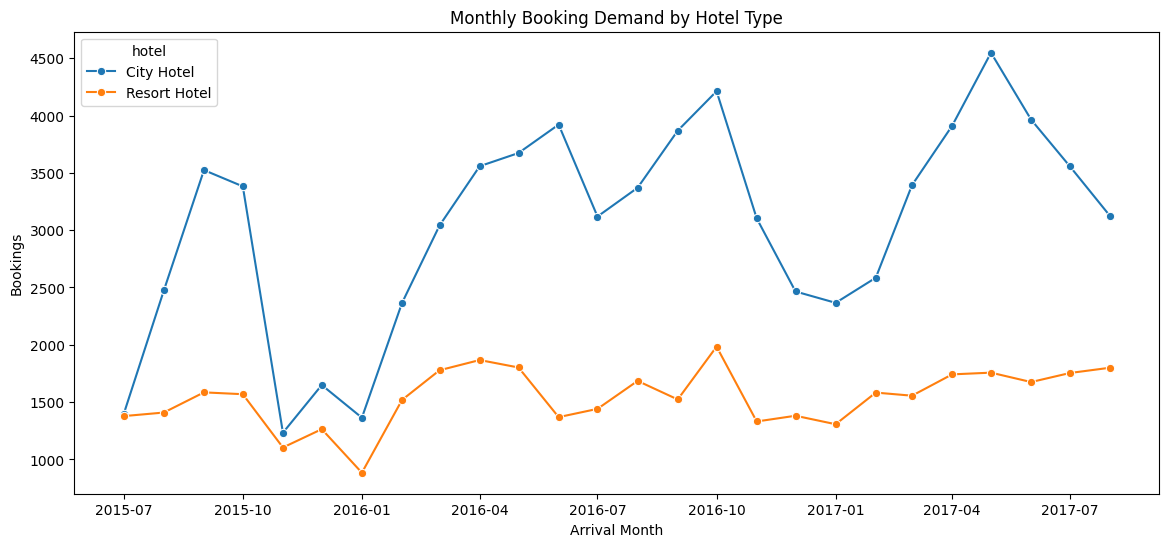

In [4]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly, x='arrival_date', y='bookings', hue='hotel', marker='o')
plt.title('Monthly Booking Demand by Hotel Type')
plt.xlabel('Arrival Month')
plt.ylabel('Bookings')
plt.show()